# 27. CNN 고정 설정 전이

13B에서 선택한 learning rate `3e-4`, dropout `0.3`, batch `16`, weight decay `1e-3`과 네 ConvBlock 구조를 고정했다. MusicGen·Udio를 각각 Train·Validation에서 빼고 CNN을 처음부터 학습한 기존 실행이다. 해당 Validation에서 epoch와 임계값을 정한 뒤 대상 Test를 평가했다. 앞서 중단한 14B 탐색과는 다른 절차이며, Main 설정 선택에는 두 대상이 포함됐던 한계가 있다.

## 1. Main 설정과 기존 입력 검증

Main `cnn_best.pt`와 `cnn_best_config.json`의 설정·manifest/cache hash가 일치해야 실행한다. 기존 10초 Log-Mel `(1,128,1001)`을 그대로 읽는다. 1001은 sample rate 24 kHz, hop 240, center STFT 조건에서 나온 실제 시간 프레임 수이며 10초만으로 고정되는 숫자가 아니다. 128 Mel bin은 handcrafted feature 128개라는 뜻이 아니다. 원곡 `original_audio` group이 split을 넘지 않는지 검사한다.

In [1]:
# Main CNN checkpoint·설정·Log-Mel cache hash를 확인하고 고정 설정 객체를 만든다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.cnn_unseen_fixed import FixedTransferCNNExperiment, HOLDOUTS, VARIANT

ROOT = Path.cwd()
RUN_ID = "cnn_unseen_fixed_20260919T173228Z"
experiment = FixedTransferCNNExperiment(ROOT, RUN_ID)
run_config = json.loads(experiment.config_path.read_text(encoding="utf-8"))
print("run_id:", RUN_ID, "| device:", experiment.device)
print("protocol SHA-256:", run_config["protocol_sha256"])
print("main checkpoint SHA-256:", run_config["main_checkpoint_sha256"])
print("main config SHA-256:", run_config["main_best_config_sha256"])
print("fixed config:", experiment.fixed_config)
# 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
print("cached Log-Mel shape:", np.load(experiment.cache_path, mmap_mode="r").shape)

run_id: cnn_unseen_fixed_20260919T173228Z | device: mps
protocol SHA-256: 098fa65192f65fddbf7d65757eb5c6b5c2b1149f79178c27746b4e328ee54a5e
main checkpoint SHA-256: 3268924f7eb57020387c1cfdd305a795378c8d71738e11cf91dafc0118f7c420
main config SHA-256: 25b28d31d48453c1cafa872f4815b41cf317de60052c310944c75eb4fd9a4003
fixed config: {'lr': 0.0003, 'dropout': 0.3, 'batch_size': 16, 'weight_decay': 0.001, 'max_epochs': 30, 'patience': 4, 'optimizer': 'AdamW', 'architecture': 'historical_4_conv_blocks'}
cached Log-Mel shape: (10077, 128, 1001)


실행 ID는 `cnn_unseen_fixed_20260919T173228Z`, 장치는 `mps`였다. 기존 Log-Mel cache shape는 **(10077, 128, 1001)**이고, Main CNN checkpoint SHA-256은 `3268924f7eb57020387c1cfdd305a795378c8d71738e11cf91dafc0118f7c420`, 새 프로토콜 SHA-256은 `098fa65192f65fddbf7d65757eb5c6b5c2b1149f79178c27746b4e328ee54a5e`였다. 고정 설정은 LR `3e-4`, dropout `0.3`, batch `16`, weight decay `1e-3`, AdamW, max epoch `30`, patience `4`로 검증됐다.

13B의 선택 설정과 manifest/cache 표현을 그대로 가져왔다. Main checkpoint는 **설정 검증에만 읽었고 가중치를 새 모델로 복사하지 않았다.** Log-Mel의 1001 time frame은 기존 24 kHz·hop 240·center STFT 설정에서 나온 실제 cache shape다.

Main 설정은 MusicGen/Udio가 포함된 Validation에서 선택됐다. 따라서 대상 생성기를 새 학습에서 제외했어도 하이퍼파라미터 선택까지 미노출된 실험은 아니다. hash 일치는 출처 차이의 영향을 제거하지 않는다.

## 2. 대상 생성기 제외와 Train class weighting

MusicGen/Udio를 각각 독립 실험으로 본다. 대상 생성기 FAKE 행은 기존 Train과 Validation에서만 제거하고 다른 행과 원래 split을 유지한다. 삭제된 행을 Test로 옮기지 않는다. CNN `BCEWithLogitsLoss(pos_weight=Train_REAL_segment/Train_FAKE_segment)`는 모델 학습에 실제 사용되는 대상별 Train segment 수로 계산한다. FAKE가 더 많으면 pos_weight는 1보다 작을 수 있다.

In [2]:
# 대상 FAKE를 제거한 Train/Validation의 Segment·Track 수를 기록한다.
mask_rows = []
for holdout in HOLDOUTS:
    # 대상 생성기 FAKE를 Train과 Validation에서 제외한다.
    train, val = experiment.filtered_data(holdout)
    for split, frame in [("train", train), ("val", val)]:
        mask_rows.append(
            dict(
                holdout_generator=holdout,
                split=split,
                n_segments=len(frame),
                n_tracks=frame.track_sample_id.nunique(),
                n_original_audio=frame.original_audio.nunique(),
                n_real_segments=int((frame.label_id == 0).sum()),
                n_fake_segments=int((frame.label_id == 1).sum()),
                n_real_tracks=frame.loc[
                    frame.label_id == 0, "track_sample_id"
                ].nunique(),
                n_fake_tracks=frame.loc[
                    frame.label_id == 1, "track_sample_id"
                ].nunique(),
                target_fake_rows=int(
                    ((frame.label_id == 1) & (frame.generator == holdout)).sum()
                ),
            )
        )
mask_summary = pd.DataFrame(mask_rows)
mask_summary.to_csv(
    experiment.result_dir / "filtered_train_val_counts.csv", index=False
)
display(mask_summary)

,holdout_generator,split,n_segments,n_tracks,n_original_audio,n_real_segments,n_fake_segments,n_real_tracks,n_fake_tracks,target_fake_rows
0,musicgen,train,6352,2187,207,621,5731,207,1980,0
1,musicgen,val,1409,484,44,132,1277,44,440,0
2,udio,train,6355,2188,207,621,5734,207,1981,0
3,udio,val,1394,479,44,132,1262,44,435,0


- **musicgen**: Train 6,352 Segment (REAL 621, FAKE 5,731), Validation 1,409 Segment (REAL 132, FAKE 1,277); target FAKE 행 **0/0**.
- **udio**: Train 6,355 Segment (REAL 621, FAKE 5,734), Validation 1,394 Segment (REAL 132, FAKE 1,262); target FAKE 행 **0/0**.

대상 FAKE가 두 split에서 모두 제거됐고 다른 데이터는 기존 group split에 남았다. 각 모델의 pos_weight는 대응 Train segment의 REAL/FAKE 비율에서 새로 계산됐다.

FAKE가 다수 class이고 source/genre/codec 차이가 남는다. class weighting은 track 길이별 기여도 차이를 모두 제거하지 않는다.

## 3. Fresh CNN 학습과 Validation epoch 선택

`LogMelCNN`은 ConvBlock 4개 `(1→16→32→64→128)`와 AdaptiveAvgPool, dropout, Linear classifier를 쓴다. 각 batch에서 forward로 FAKE logit을 구하고, 대상별 Train `pos_weight` BCE loss를 계산한 뒤 backward로 gradient를 얻고 AdamW optimizer step으로 가중치를 갱신한다. 구현은 `src/cnn_unseen_revised.py`의 함수 주석에 단계별로 기록했다. DataLoader worker는 0, Train에서만 shuffle, seed는 42다. seed 하나가 장치별 완전 재현을 보장하지 않는다.

각 대상의 모델은 Main checkpoint **가중치를 로드하지 않고** 새 초기화한다. 최대 30 epoch, patience 4이며 대상별 필터된 Validation Track EER 최소 → AUC 최대 → 이른 epoch 순서로 최고 checkpoint를 저장한다. 저장된 checkpoint를 복원해 Segment·Track 임계값을 별도로 고른다. Test 정보는 여기서 사용하지 않는다.

In [3]:
# 대상별 CNN을 새 가중치로 학습하고 Train pos_weight·Validation 선택을 Test 전에 동결한다.
selections = {}
for holdout in HOLDOUTS:
    # 대상별로 고정 설정의 새 모델을 학습한다.
    selections[holdout] = experiment.fit_holdout(holdout)
# 두 대상의 checkpoint·임계값을 모두 검증하고 Test 전에 동결한다.
frozen = experiment.freeze_both()
selection_rows = []
for holdout, item in frozen.items():
    row = item["trial"]
    selection_rows.append(
        dict(
            holdout_generator=holdout,
            variant=VARIANT,
            lr=row["lr"],
            dropout=row["dropout"],
            batch_size=row["batch_size"],
            weight_decay=row["weight_decay"],
            best_epoch=row["best_epoch"],
            epochs_run=row["epochs_run"],
            updates=row["updates"],
            train_real=row["train_real"],
            train_fake=row["train_fake"],
            # 양성(FAKE) 손실 가중치는 해당 Train의 REAL/FAKE 수로 정한다.
            pos_weight=row["pos_weight"],
            val_segment_auc=row["segment_roc_auc"],
            val_segment_eer=row["segment_eer"],
            val_track_auc=row["track_roc_auc"],
            val_track_eer=row["track_eer"],
            val_track_macro_f1=row["track_macro_f1"],
            segment_threshold=item["thresholds"]["segment"],
            track_threshold=item["thresholds"]["track"],
            elapsed_sec=row["elapsed_sec"],
        )
    )
selection_summary = pd.DataFrame(selection_rows)
selection_summary.to_csv(experiment.result_dir / "selection_summary.csv", index=False)
display(selection_summary)
print(
    "Both fixed-transfer selections frozen:",
    (experiment.result_dir / "selections_frozen.json").exists(),
)

,holdout_generator,variant,lr,dropout,batch_size,weight_decay,best_epoch,epochs_run,updates,train_real,train_fake,pos_weight,val_segment_auc,val_segment_eer,val_track_auc,val_track_eer,val_track_macro_f1,segment_threshold,track_threshold,elapsed_sec
0,musicgen,fixed_hyperparameter_transfer,0.0003,0.3,16,0.001,2,6,2382,621,5731,0.108358,0.872784,0.196970,0.907748,0.136364,0.727654,0.375235,0.397884,478.441833
1,udio,fixed_hyperparameter_transfer,0.0003,0.3,16,0.001,5,9,3582,621,5734,0.108301,0.950265,0.104596,0.971055,0.068182,0.836949,0.233956,0.331730,701.719250


Both fixed-transfer selections frozen: True


- **musicgen**: 6 epoch 실행, best epoch **2**, 2,382 optimizer step, 학습 8.0분. Train REAL/FAKE 621/5731, pos_weight **0.108358**. Validation Segment AUC/EER 0.8728/0.1970, Track AUC/EER **0.9077/0.1364**; Segment/Track 임계값 **0.375235/0.397884**.
- **udio**: 9 epoch 실행, best epoch **5**, 3,582 optimizer step, 학습 11.7분. Train REAL/FAKE 621/5734, pos_weight **0.108301**. Validation Segment AUC/EER 0.9503/0.1046, Track AUC/EER **0.9711/0.0682**; Segment/Track 임계값 **0.233956/0.331730**.

두 모델 모두 Main의 LR·dropout·batch·weight decay를 고정한 fresh fit이다. 각자의 필터된 Validation에서만 EER/AUC 기준 최고 epoch와 별도 Segment·Track threshold를 선택했다.

Validation 최고 epoch 성능은 일반화 성능이 아니다. Early stopping 때문에 두 대상의 epoch 수·계산량이 다를 수 있다. seed 42가 장치별 bitwise 재현을 보장하지 않는다.

## 4. Primary Test: 동결 모델·Validation 임계값

원래 Test의 REAL **45 Track 전체**와 해당 대상 FAKE만 사용한다. MusicGen은 FAKE 45 Track(총 270 Segment), Udio는 FAKE 48 Track(총 279 Segment)이다. 동일한 Test ID는 네 모델 공통이다. Test ROC로 얻은 AUC/EER는 분리력 지표이고, Test 예측의 임계값은 **각 대상의 필터된 Validation에서 저장한 Segment·Track 임계값** 그대로다. AP는 `average_precision_score`이며 사다리꼴 PR 면적과 동일시하지 않는다. FAKE AP가 높더라도 다수 class 효과를 고려해 REAL AP와 prevalence를 함께 본다.

In [4]:
# 두 선택의 동결을 확인한 후 원래 Test REAL 전체와 대상 FAKE만 평가한다.
# 두 선택이 모두 동결되지 않았으면 이 함수는 Test score를 열지 않는다.
primary_metrics = experiment.final_test()
show = [
    "holdout_generator",
    "model",
    "variant",
    "level",
    "n",
    "n_real",
    "n_fake",
    "roc_auc",
    "ap_fake",
    "ap_real",
    "eer",
    "balanced_accuracy",
    "macro_f1",
    "real_fpr",
    "fake_miss_rate",
    "hter",
    "threshold",
    "confusion_matrix",
]
display(primary_metrics[show].sort_values(["holdout_generator", "level"]))

musicgen fixed-transfer Test Track EER=0.266667, AUC=0.771358, HTER=0.355556


udio fixed-transfer Test Track EER=0.187500, AUC=0.855093, HTER=0.221528


,holdout_generator,model,variant,level,n,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter,threshold,confusion_matrix
0,musicgen,Log-Mel CNN,fixed_hyperparameter_transfer,segment,270,135,135,0.719506,0.650621,0.750484,0.311111,0.629630,0.625603,0.266667,0.474074,0.370370,0.375235,"[[99, 36], [64, 71]]"
1,musicgen,Log-Mel CNN,fixed_hyperparameter_transfer,track,90,45,45,0.771358,0.697330,0.818056,0.266667,0.644444,0.635628,0.200000,0.511111,0.355556,0.397884,"[[36, 9], [23, 22]]"
2,udio,Log-Mel CNN,fixed_hyperparameter_transfer,segment,279,135,144,0.817284,0.803739,0.802034,0.244444,0.745370,0.740170,0.148148,0.361111,0.254630,0.233956,"[[115, 20], [52, 92]]"
3,udio,Log-Mel CNN,fixed_hyperparameter_transfer,track,93,45,48,0.855093,0.840761,0.847095,0.187500,0.778472,0.771552,0.088889,0.354167,0.221528,0.331730,"[[41, 4], [17, 31]]"


- **musicgen**: Track 90개(REAL 45, FAKE 45), Segment 270개. Track AUC/EER **0.7714/0.2667**, FAKE/REAL AP **0.6973/0.8181**, Balanced Accuracy 0.6444, Macro-F1 0.6356, REAL FPR 0.2000, FAKE miss 0.5111, HTER **0.3556**. Segment AUC/EER 0.7195/0.3111.
- **udio**: Track 93개(REAL 45, FAKE 48), Segment 279개. Track AUC/EER **0.8551/0.1875**, FAKE/REAL AP **0.8408/0.8471**, Balanced Accuracy 0.7785, Macro-F1 0.7716, REAL FPR 0.0889, FAKE miss 0.3542, HTER **0.2215**. Segment AUC/EER 0.8173/0.2444.

AUC/EER는 대상 Test의 점수 분리력이고, Balanced Accuracy·Macro-F1·FPR·miss·HTER는 **해당 대상 Validation 임계값**을 그대로 적용한 분류 결과다. Track 점수는 같은 track Segment score의 평균이다. FAKE AP와 REAL AP를 각 class 비율과 함께 본다.

23번 전체 Test와 대상별 subset은 표본·class 비율이 달라 직접 수치 비교하지 않는다. Main 하이퍼파라미터 선택에 대상 생성기 Validation이 포함됐고 과거 Test 결과도 공개됐다. REAL은 45 Track으로 작으며 FMA/Echoes TTA 출처 차이가 남는다. Udio REAL 21 원곡 group에는 해당 FAKE 짝이 없다.

## 5. Udio 원곡 대응 보조 분석

Udio FAKE는 24개 원곡 group에만 있다. 해당 group의 REAL 24 Track과 Udio FAKE 48 Track을 primary 저장 점수에서 추려 보조 평가한다. 모델 재추론·선택·임계값 조정은 하지 않는다. 이 subset은 조건화된 작은 표본이므로 primary 결과를 대체하지 않는다.

In [5]:
# Udio 원곡 대응 subset을 저장된 Test score에서만 추려 보조 평가한다.
paired_metrics = experiment.paired_source_test()
display(
    paired_metrics[
        [
            "holdout_generator",
            "level",
            "n",
            "n_real",
            "n_fake",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "hter",
            "threshold",
        ]
    ]
)

,holdout_generator,level,n,n_real,n_fake,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter,threshold
0,udio,segment,216,72,144,0.857157,0.201389,0.777778,0.727534,0.083333,0.361111,0.222222,0.233956
1,udio,track,72,24,48,0.887153,0.145833,0.802083,0.746875,0.041667,0.354167,0.197917,0.331730


Udio 원곡 대응 subset의 Track은 **72개**(REAL 24, FAKE 48)이고 AUC/EER **0.8872/0.1458**, HTER **0.1979**였다. 모든 REAL 45개를 사용한 primary Udio Track 93개에서는 AUC/EER **0.8551/0.1875**, HTER **0.2215**였다.

두 값은 REAL 원곡 coverage가 다른 cohort에서 계산됐다. 보조 subset은 이미 저장된 primary score를 필터했고 동일 checkpoint와 Validation 임계값을 사용했다.

subset은 FAKE가 있는 원곡으로 조건화되고 class 비율도 다르다. 더 좋은 쪽을 선택 결과로 삼지 않는다.

## 6. 학습 곡선과 대상별 Test 비교

학습 epoch별 Train loss와 Validation Track EER를 저장해 checkpoint 선택 과정을 보여준다. Test Track EER를 대상별로 별도 막대에 나타낸다. 그림은 추가 선택에 사용하지 않는다.

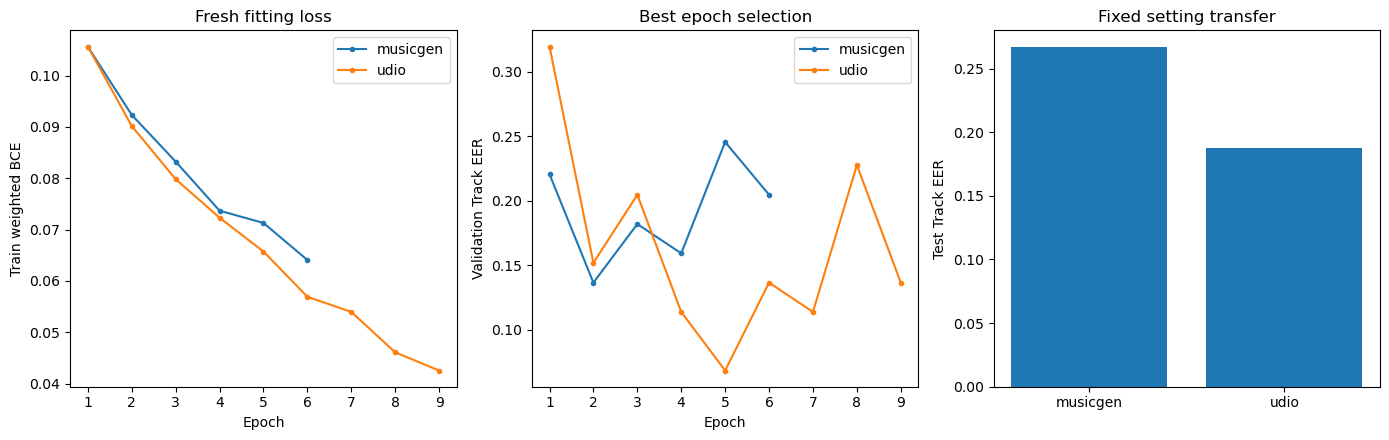

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/cnn_unseen_fixed_transfer/cnn_unseen_fixed_20260919T173228Z/cnn_unseen_fixed_training_test.png


In [6]:
# Train loss·Validation EER과 Test EER을 구분해 그림으로 저장한다.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for holdout in HOLDOUTS:
    hist = pd.read_csv(experiment.result_dir / holdout / "epoch_history.csv")
    axes[0].plot(hist.epoch, hist.train_loss, marker=".", label=holdout)
    axes[1].plot(hist.epoch, hist.val_track_eer, marker=".", label=holdout)
axes[0].set(xlabel="Epoch", ylabel="Train weighted BCE", title="Fresh fitting loss")
axes[1].set(xlabel="Epoch", ylabel="Validation Track EER", title="Best epoch selection")
for ax in axes[:2]:
    ax.legend()
track = primary_metrics[primary_metrics.level == "track"].sort_values(
    "holdout_generator"
)
axes[2].bar(track.holdout_generator, track.eer)
axes[2].set(ylabel="Test Track EER", title="Fixed setting transfer")
fig.tight_layout()
plot_path = experiment.result_dir / "cnn_unseen_fixed_training_test.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

두 대상의 Train loss·Validation Track EER epoch 곡선과 primary Test Track EER 그림을 저장했다. 선택 epoch는 MusicGen **2**, Udio **5**이며, Test Track EER는 각각 **0.2667**, **0.1875**였다.

![고정 설정 CNN 학습 곡선과 대상별 Test Track EER](../results/cnn_unseen_fixed_transfer/cnn_unseen_fixed_20260919T173228Z/cnn_unseen_fixed_training_test.png)

Train 손실은 최적화 진행을, Validation EER는 checkpoint 선택을, Test EER는 동결된 모델의 대상 cohort 분리력을 보여준다.

두 대상의 Test FAKE와 원곡 coverage가 달라 차이를 생성기 자체의 난도로 단정할 수 없다. 그림에 원곡 단위 신뢰구간은 없다.